In [1]:
import tensorflow as tf
import pathlib

dataset_url = "http://download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir)

#Como las clases están dentro de una subcarpeta 'flower_photos'
data_dir = data_dir / 'flower_photos'

print(f"Directorio de imágenes: {data_dir}")
print(f"Carpetas de clases: {[f.name for f in data_dir.iterdir() if f.is_dir()]}")

Directorio de imágenes: /root/.keras/datasets/flower_photos/flower_photos
Carpetas de clases: ['roses', 'tulips', 'daisy', 'sunflowers', 'dandelion']


In [2]:
# Contar imágenes por clase
import os

print("Cantidad de imágenes por clase:")
print("-" * 30)

for clase in ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']:
    clase_path = data_dir / clase
    if clase_path.exists():
        num_imagenes = len(list(clase_path.glob('*.jpg')))
        print(f"{clase}: {num_imagenes} imágenes")
    else:
        print(f"{clase}: Carpeta no encontrada")

print("-" * 30)
total = sum(len(list((data_dir / clase).glob('*.jpg'))) for clase in ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips'] if (data_dir / clase).exists())
print(f"Total: {total} imágenes")

Cantidad de imágenes por clase:
------------------------------
daisy: 633 imágenes
dandelion: 898 imágenes
roses: 641 imágenes
sunflowers: 699 imágenes
tulips: 799 imágenes
------------------------------
Total: 3670 imágenes


In [3]:
#Se crea el set de entrenamiento (80%)
train = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(180, 180),
    batch_size=32
)

#Se crea el set de validaciones (20%)
validation = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(180, 180),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


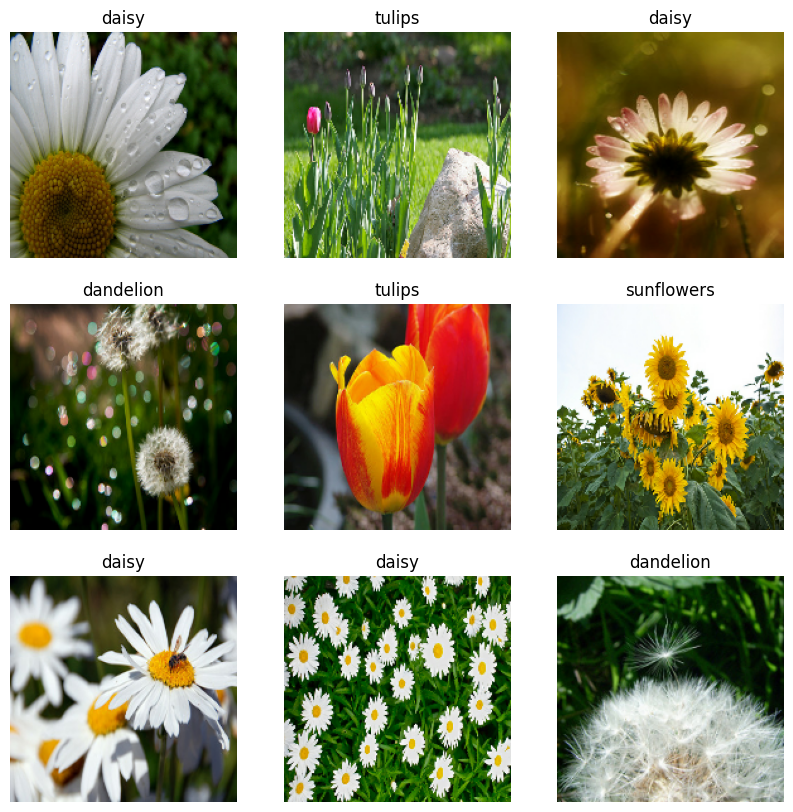

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train.class_names[labels[i]])
        plt.axis("off")
plt.show()

In [5]:
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

clases = 5

model = models.Sequential([
    # Capa Input explícita
    layers.Input(shape=(180, 180, 3)),
    
    # Preprocesamiento: reescalado de 0-255 a 0-1
    layers.Rescaling(1./255),
    
    # Data augmentation para más variedad
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    
    # Bloque 1
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    
    # Bloque 2
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    
    # Bloque 3
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    
    # Clasificador
    layers.Flatten(),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(clases, activation='softmax')
])

In [6]:
#Compilamos el modelo

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 180, 180, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 180, 180, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 90, 90, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 45, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 8,035,525 (30.65 MB)

 Trainable params: 8,034,629 (30.65 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

#Agregamos EarlyStopping para evitar sobreajuste en el modelo
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 8,
    restore_best_weights = True,
    verbose = 1
)

history = model.fit(
  train,
  validation_data = validation,
  epochs = 50,
  callbacks = [early_stop]
)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 127ms/step - accuracy: 0.3045 - loss: 2.6138 - val_accuracy: 0.2602 - val_loss: 3.4678
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.3791 - loss: 2.2669 - val_accuracy: 0.2602 - val_loss: 3.7685
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.4026 - loss: 2.1209 - val_accuracy: 0.2602 - val_loss: 2.9008
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.4261 - loss: 1.9873 - val_accuracy: 0.2861 - val_loss: 2.3721
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.4649 - loss: 1.8891 - val_accuracy: 0.3243 - val_loss: 2.1452
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.4877 - loss: 1.7762 - val_accuracy: 0.4877 - val_loss: 1.7449
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.4946 - loss: 1.7001 - val_accuracy: 0.5817 - val_loss: 1.5718
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.5109 - loss: 1.6399 - val_accu

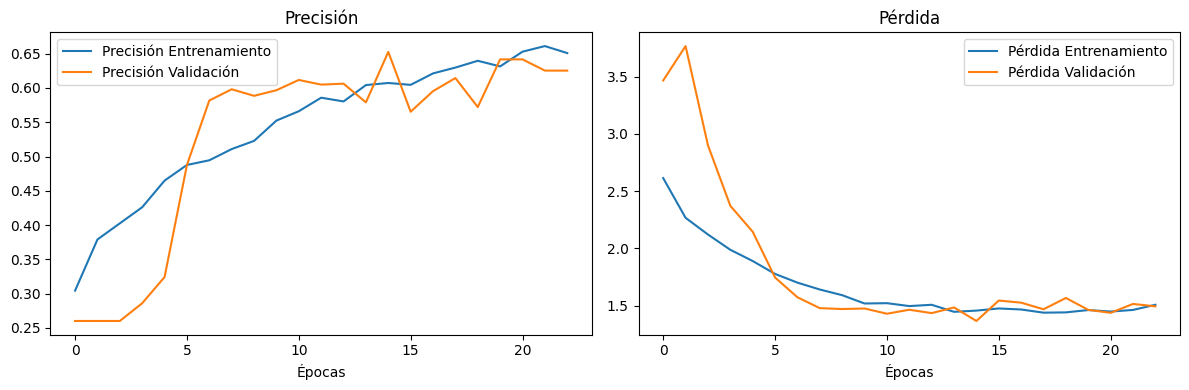

Mejor precisión de validación: 0.6526
Épocas entrenadas: 23


In [8]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))  # Usar la longitud real del entrenamiento

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend()
plt.title('Precisión')
plt.xlabel('Épocas')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend()
plt.title('Pérdida')
plt.xlabel('Épocas')

plt.tight_layout()
plt.show()

print(f"Mejor precisión de validación: {max(val_acc):.4f}")
print(f"Épocas entrenadas: {len(acc)}")

In [9]:
#Extraer los nombres de las clases
nombreClases = train.class_names
print(f"Las clases presentes son: {nombreClases}")

Las clases presentes son: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [10]:
# Evaluar el modelo en el conjunto de validación
val_loss, val_accuracy = model.evaluate(validation, verbose=0)
print(f"Precisión en validación: {val_accuracy:.4f}")
print(f"Pérdida en validación: {val_loss:.4f}")

# También podemos evaluar clase por clase (opcional)
from sklearn.metrics import classification_report
import numpy as np

# Obtener predicciones para todo el conjunto de validación
y_true = []
y_pred = []

for images, labels in validation:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Reporte por clase
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=train.class_names))

Precisión en validación: 0.6526
Pérdida en validación: 1.3648

Reporte de clasificación por clase:
              precision    recall  f1-score   support

       daisy       0.50      0.67      0.58       107
   dandelion       0.64      0.77      0.70       191
       roses       0.65      0.50      0.57       119
  sunflowers       0.75      0.87      0.80       135
      tulips       0.75      0.45      0.56       182

    accuracy                           0.65       734
   macro avg       0.66      0.65      0.64       734
weighted avg       0.67      0.65      0.64       734



In [11]:
from google.colab import drive
drive.mount('/content/drive')

# Guardar el modelo en Drive
model.save('/content/drive/MyDrive/modelo_flores.keras')
print("Modelo guardado en: /content/drive/MyDrive/modelo_flores.keras")

Mounted at /content/drive
Modelo guardado en: /content/drive/MyDrive/modelo_flores.keras


In [12]:
import json

# Guardar los nombres de las clases
with open('/content/drive/MyDrive/class_names.json', 'w') as f:
    json.dump(train.class_names, f)
print("Nombres de clases guardados en: /content/drive/MyDrive/class_names.json")

# Verificar que se guardaron correctamente
print(f"Clases: {train.class_names}")

Nombres de clases guardados en: /content/drive/MyDrive/class_names.json
Clases: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
